# EDAノートブック

本ノートブックは、分析業務で使うEDAを固定手順で実行するための定型版です。
可視化結果は相対パスで `reports/figures` に保存します。


## 固定EDA計画
1. データ読み込みと基本確認
2. 列型・記述統計の確認
3. 欠損率の集計と可視化
4. 数値列の分布確認
5. カテゴリ列の主要分布確認
6. 目的変数の分布と偏り確認
7. 数値特徴量の相関確認
8. 日付列の時系列傾向確認（存在時）
9. 観察結果サマリ


In [1]:
from pathlib import Path
import warnings

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")
warnings.filterwarnings("ignore", message="Glyph .* missing from font")
plt.rcParams["axes.unicode_minus"] = False

JP_FONT_CANDIDATES = [
    "Yu Gothic",
    "Meiryo",
    "MS Gothic",
    "Noto Sans CJK JP",
    "IPAexGothic",
    "IPAGothic",
    "TakaoGothic",
]


def configure_japanese_font() -> str:
    available = {f.name for f in fm.fontManager.ttflist}
    for name in JP_FONT_CANDIDATES:
        if name in available:
            plt.rcParams["font.family"] = name
            return name
    plt.rcParams["font.sans-serif"] = JP_FONT_CANDIDATES + list(plt.rcParams.get("font.sans-serif", []))
    return ""


selected_font = configure_japanese_font()
if selected_font:
    print(f"日本語フォント: {selected_font}")
else:
    print("日本語フォント候補が見つからないため、既定フォントで描画します。")

ENCODINGS = ("utf-8-sig", "utf-8", "cp932", "shift_jis", "euc_jp")

cwd = Path.cwd()
if (cwd / "configs" / "project_config.json").exists():
    analysis_root = cwd
elif (cwd.name == "notebooks") and (cwd.parent / "configs" / "project_config.json").exists():
    analysis_root = cwd.parent
elif (cwd / "artifacts" / "analysis_project" / "configs" / "project_config.json").exists():
    analysis_root = cwd / "artifacts" / "analysis_project"
else:
    analysis_root = cwd

FIG_DIR = analysis_root / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def load_csv_auto(path: Path):
    sep = "	" if path.suffix.lower() == ".tsv" else ","
    for enc in ENCODINGS:
        try:
            return pd.read_csv(path, encoding=enc, sep=sep), enc
        except UnicodeDecodeError:
            continue
    raise RuntimeError("CSVを既知エンコーディングで読み込めませんでした")


def is_pure_day_number_column(series: pd.Series) -> bool:
    numeric = pd.to_numeric(series, errors="coerce").dropna()
    if numeric.empty:
        return False
    if not np.all(np.isclose(numeric, np.round(numeric))):
        return False
    return bool(((numeric >= 1) & (numeric <= 31)).all())


日本語フォント: Yu Gothic


In [2]:
csv_rel = Path("data/train.csv")
candidates = [
    analysis_root / csv_rel,
    Path("data/train.csv"),
    Path("artifacts/analysis_project") / csv_rel,
]
csv_path = next((p for p in candidates if p.exists()), candidates[0])
df, used_encoding = load_csv_auto(csv_path)
target_col = "charges"
if target_col not in df.columns:
    target_col = df.columns[-1]
date_col_hint = "None".strip() or None

print(f"読み込みエンコーディング: {used_encoding}")
print(f"行数: {len(df):,} / 列数: {df.shape[1]:,}")
print(f"目的変数列: {target_col}")
display(df.head(10))


読み込みエンコーディング: utf-8-sig
行数: 1,600 / 列数: 8
目的変数列: charges


,id,age,sex,bmi,children,smoker,region,charges
0,0,26,male,32.665465,3,no,southeast,0
1,1,41,male,29.798725,1,no,southwest,0
2,2,28,male,32.722029,0,yes,northwest,1
3,3,20,female,38.429831,2,no,southeast,0
4,4,45,female,29.641854,1,no,northwest,0
5,5,20,male,37.785937,2,yes,southeast,1
6,6,37,male,43.393374,2,no,northeast,0
7,7,41,female,32.280407,1,no,northeast,0
8,8,40,male,28.865828,1,no,northeast,0
9,9,54,female,33.870887,2,no,northeast,0


## 1. データ概要


In [3]:
try:
    import math
    from pathlib import Path

    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

    print('【データ概要】')
    print(f'行数: {df.shape[0]}')
    print(f'列数: {df.shape[1]}')
    print('\n【列情報】')
    info_df = pd.DataFrame({
        '列名': df.columns,
        '型': [str(df[c].dtype) for c in df.columns],
        '欠損数': [int(df[c].isna().sum()) for c in df.columns],
        '欠損率(%)': [float(df[c].isna().mean() * 100) for c in df.columns],
        'ユニーク数': [int(df[c].nunique(dropna=True)) for c in df.columns]
    })
    print(info_df)

    print('\n【先頭5行】')
    print(df.head())

    print('\n【基本統計量】')
    print(df.describe(include='all').transpose())
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: overview_code: {_eda_exc}")
    dtype_summary = (
        df.dtypes.astype(str)
        .rename("dtype")
        .reset_index()
        .rename(columns={"index": "column"})
    )
    type_counts = dtype_summary["dtype"].value_counts().rename_axis("dtype").reset_index(name="count")
    print("列型サマリ")
    display(type_counts)
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    category_cols = [c for c in df.columns if c not in numeric_cols]
    print(f"数値列数: {len(numeric_cols)} / カテゴリ列数: {len(category_cols)}")
    display(dtype_summary.head(30))


【データ概要】


行数: 1600
列数: 8

【列情報】
         列名        型  欠損数  欠損率(%)  ユニーク数
0        id    int64    0     0.0   1600
1       age    int64    0     0.0     47
2       sex      str    0     0.0      2
3       bmi  float64    0     0.0   1600
4  children    int64    0     0.0      6
5    smoker      str    0     0.0      2
6    region      str    0     0.0      4
7   charges    int64    0     0.0      3

【先頭5行】
   id  age     sex        bmi  children smoker     region  charges
0   0   26    male  32.665465         3     no  southeast        0
1   1   41    male  29.798725         1     no  southwest        0
2   2   28    male  32.722029         0    yes  northwest        1
3   3   20  female  38.429831         2     no  southeast        0
4   4   45  female  29.641854         1     no  northwest        0

【基本統計量】
           count unique        top  freq       mean        std        min  \
id        1600.0    NaN        NaN   NaN  1007.8625  575.26841        0.0   
age       1600.0    NaN        NaN 

## 2. 欠損分析


【欠損値サマリー】
Empty DataFrame
Columns: [欠損数, 欠損率(%)]
Index: []


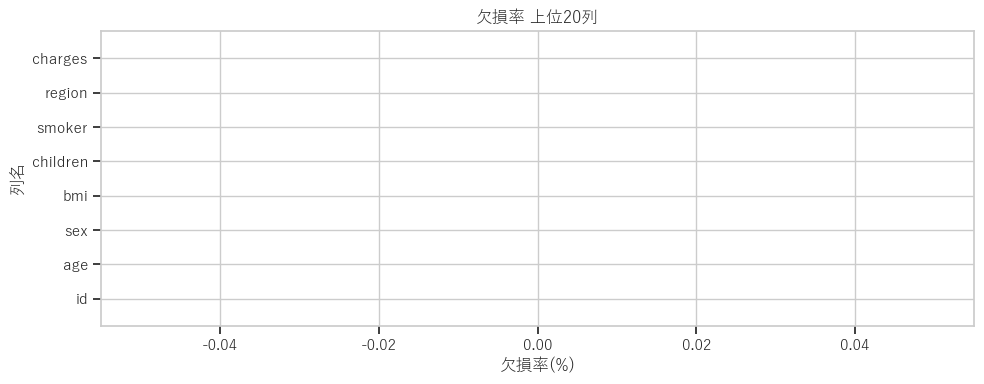

In [4]:
try:
    from pathlib import Path

    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

    missing_cnt = df.isna().sum().sort_values(ascending=False)
    missing_rate = (df.isna().mean() * 100).sort_values(ascending=False)
    missing_df = pd.DataFrame({'欠損数': missing_cnt, '欠損率(%)': missing_rate})
    print('【欠損値サマリー】')
    print(missing_df[missing_df['欠損数'] > 0])

    plot_df = missing_df.head(20).sort_values('欠損率(%)', ascending=True)
    plt.figure(figsize=(10, max(4, len(plot_df) * 0.35)))
    plt.barh(plot_df.index.astype(str), plot_df['欠損率(%)'], color='tomato')
    plt.xlabel('欠損率(%)')
    plt.ylabel('列名')
    plt.title('欠損率 上位20列')
    plt.tight_layout()
    plt.savefig(Path(FIG_DIR) / 'missing_rate_top20.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: missing_code: {_eda_exc}")
    missing_rate = (df.isna().mean() * 100).sort_values(ascending=False)
    display(missing_rate.rename("欠損率(%)").to_frame().head(20))
    top_missing = missing_rate.head(20)
    fig, ax = plt.subplots(figsize=(12, 5))
    top_missing.plot(kind="bar", ax=ax, color="#4c78a8")
    ax.set_title("欠損率 上位20列")
    ax.set_ylabel("欠損率(%)")
    ax.set_xlabel("列名")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "missing_rate_top20.png", dpi=160, bbox_inches="tight")
    plt.show()


## 3. 数値特徴量の分布


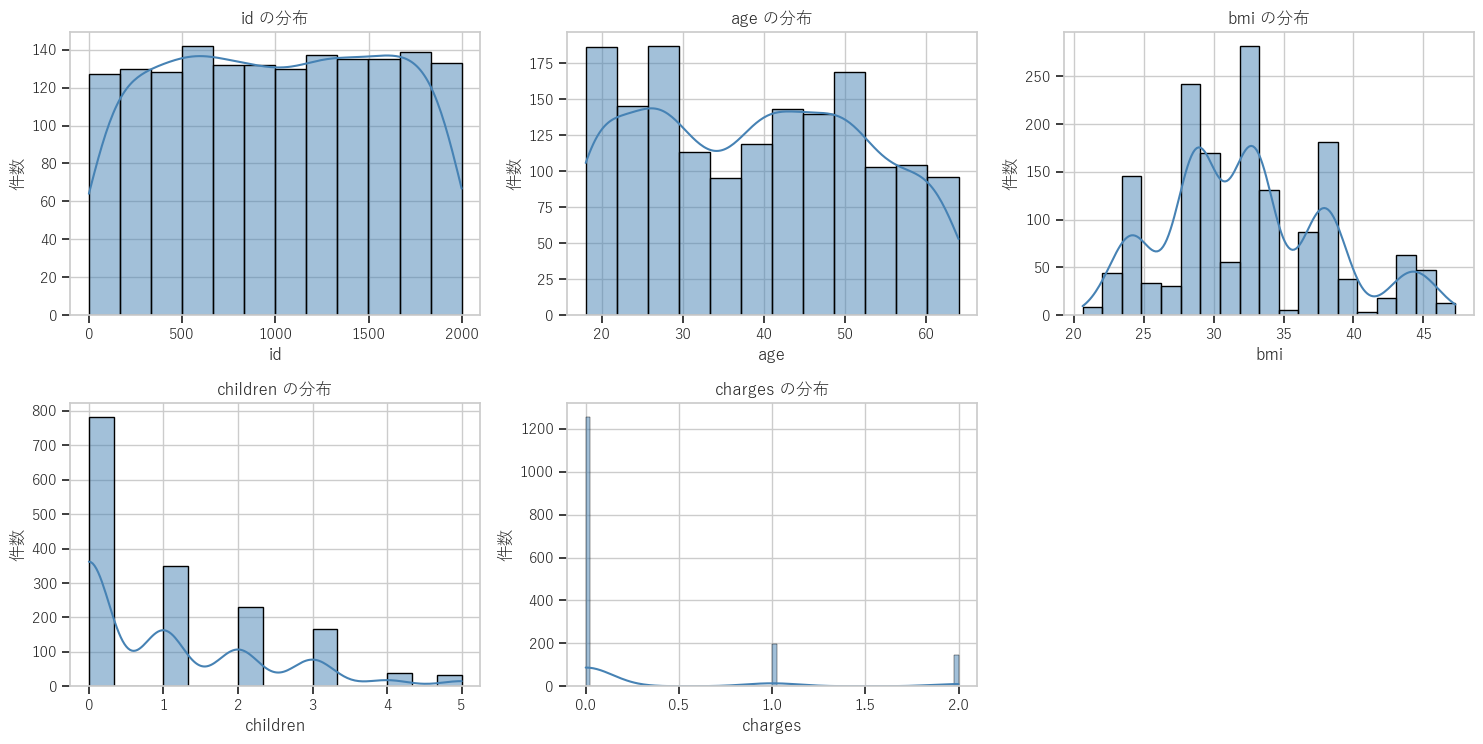

【数値列サマリー】
           count         mean         std        min         25%          50%  \
id        1600.0  1007.862500  575.268410   0.000000  515.750000  1010.500000   
age       1600.0    38.985000   13.555012  18.000000   27.000000    40.000000   
bmi       1600.0    32.424376    5.766915  20.627626   28.634267    32.268786   
children  1600.0     1.014375    1.259031   0.000000    0.000000     1.000000   
charges   1600.0     0.306250    0.628656   0.000000    0.000000     0.000000   

                  75%          max  
id        1509.250000  1999.000000  
age         50.000000    64.000000  
bmi         37.069581    47.290644  
children     2.000000     5.000000  
charges      0.000000     2.000000  


In [5]:
try:
    import math
    from pathlib import Path

    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    plot_cols = num_cols[:6]

    if len(plot_cols) > 0:
        n = len(plot_cols)
        ncols = 3 if n >= 3 else n
        nrows = math.ceil(n / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.8 * nrows))
        axes = np.array(axes).reshape(-1)
        for ax, col in zip(axes, plot_cols):
            series = df[col].dropna()
            sns.histplot(series, kde=True, ax=ax, color='steelblue')
            ax.set_title(f'{col} の分布')
            ax.set_xlabel(col)
            ax.set_ylabel('件数')
        for ax in axes[len(plot_cols):]:
            ax.axis('off')
        plt.tight_layout()
        plt.savefig(Path(FIG_DIR) / 'numeric_distribution_top6.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

    print('【数値列サマリー】')
    if len(num_cols) > 0:
        print(df[num_cols].describe().transpose())
    else:
        print(pd.DataFrame())
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: numeric_code: {_eda_exc}")
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    if numeric_cols:
        display(df[numeric_cols].describe().T.head(20))
    target_col_local = "charges"
    if target_col_local not in df.columns:
        target_col_local = df.columns[-1]
    plot_cols = [c for c in numeric_cols if c != target_col_local][:6]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < len(plot_cols):
            col = plot_cols[i]
            sns.histplot(df[col], bins=30, ax=ax, color="#1f77b4")
            ax.set_title(f"{col} の分布")
        else:
            ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "numeric_distribution_top6.png", dpi=160, bbox_inches="tight")
    plt.show()


## 4. カテゴリ特徴量の分布


In [6]:
try:
    import math
    from pathlib import Path

    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

    cat_cols = [c for c in df.columns if c != target_col and (df[c].dtype == 'object' or str(df[c].dtype) == 'category')]
    plot_cols = cat_cols[:3]

    if len(plot_cols) > 0:
        n = len(plot_cols)
        fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
        if n == 1:
            axes = [axes]
        for ax, col in zip(axes, plot_cols):
            vc = df[col].fillna('欠損').value_counts().head(15)
            sns.barplot(x=vc.values, y=vc.index.astype(str), ax=ax, color='mediumpurple')
            ax.set_title(f'{col} のカテゴリ分布')
            ax.set_xlabel('件数')
            ax.set_ylabel(col)
        plt.tight_layout()
        plt.savefig(Path(FIG_DIR) / 'categorical_distribution_top3.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

    print('【カテゴリ列サマリー】')
    summary = []
    for col in cat_cols:
        summary.append({
            '列名': col,
            'ユニーク数': int(df[col].nunique(dropna=True)),
            '最頻値': None if df[col].dropna().empty else df[col].mode(dropna=True).iloc[0],
            '最頻値件数': 0 if df[col].dropna().empty else int(df[col].value_counts(dropna=True).iloc[0])
        })
    print(pd.DataFrame(summary))
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: categorical_code: {_eda_exc}")
    category_cols = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
    plot_cols = category_cols[:3]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for i, ax in enumerate(axes):
        if i < len(plot_cols):
            col = plot_cols[i]
            vc = df[col].astype(str).fillna("欠損").value_counts().head(10)
            vc.plot(kind="bar", ax=ax, color="#59a14f")
            ax.set_title(f"{col} 上位カテゴリ")
            ax.tick_params(axis="x", rotation=45)
        else:
            ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "categorical_distribution_top3.png", dpi=160, bbox_inches="tight")
    plt.show()


【カテゴリ列サマリー】
Empty DataFrame
Columns: []
Index: []


## 5. 目的変数分析


【目的変数の確認】
目的変数名: charges

【目的変数サマリー】
count    1600.000000
mean        0.306250
std         0.628656
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         2.000000
Name: charges, dtype: float64

【目的変数の度数】
charges
0    1256
1     198
2     146
Name: count, dtype: int64


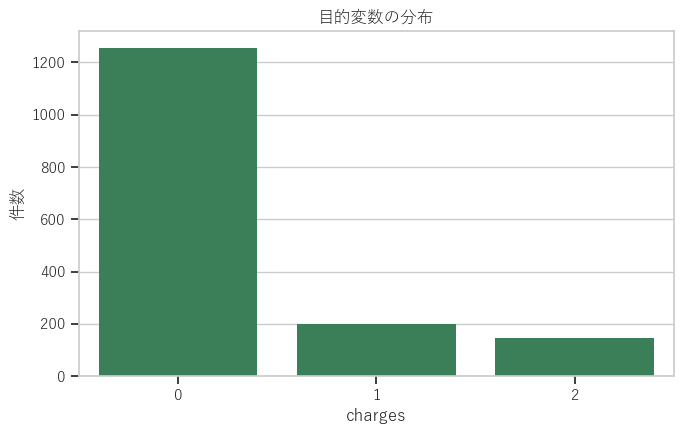

In [7]:
try:
    from pathlib import Path

    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

    print('【目的変数の確認】')
    print(f'目的変数名: {target_col}')

    if target_col in df.columns:
        y = df[target_col]
        print('\n【目的変数サマリー】')
        print(y.describe())
        print('\n【目的変数の度数】')
        print(y.value_counts(dropna=False).sort_index())

        plt.figure(figsize=(7, 4.5))
        if pd.api.types.is_numeric_dtype(y):
            unique_count = y.nunique(dropna=True)
            if unique_count <= 10:
                vc = y.value_counts(dropna=False).sort_index()
                sns.barplot(x=vc.index.astype(str), y=vc.values, color='seagreen')
                plt.xlabel(target_col)
                plt.ylabel('件数')
                plt.title('目的変数の分布')
            else:
                sns.histplot(y.dropna(), kde=True, color='seagreen')
                plt.xlabel(target_col)
                plt.ylabel('件数')
                plt.title('目的変数の分布')
        else:
            vc = y.fillna('欠損').value_counts()
            sns.barplot(x=vc.index.astype(str), y=vc.values, color='seagreen')
            plt.xlabel(target_col)
            plt.ylabel('件数')
            plt.title('目的変数の分布')
        plt.tight_layout()
        plt.savefig(Path(FIG_DIR) / 'target_distribution.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: target_code: {_eda_exc}")
    series = df[target_col]
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    if pd.api.types.is_numeric_dtype(series):
        uniq = series.dropna().nunique()
        if uniq > 20:
            sns.histplot(series.dropna(), bins=30, ax=ax[0], color="#f28e2b")
            ax[0].set_title("目的変数ヒストグラム")
            sns.boxplot(x=series.dropna(), ax=ax[1], color="#e15759")
            ax[1].set_title("目的変数ボックスプロット")
        else:
            vc = series.value_counts(dropna=False).sort_index()
            vc.plot(kind="bar", ax=ax[0], color="#f28e2b")
            ax[0].set_title("目的変数カテゴリ分布")
            (vc / vc.sum() * 100).round(2).plot(kind="bar", ax=ax[1], color="#e15759")
            ax[1].set_title("目的変数カテゴリ比率(%)")
    else:
        vc = series.astype(str).fillna("欠損").value_counts().head(20)
        vc.plot(kind="bar", ax=ax[0], color="#f28e2b")
        ax[0].set_title("目的変数カテゴリ分布")
        (vc / vc.sum() * 100).round(2).plot(kind="bar", ax=ax[1], color="#e15759")
        ax[1].set_title("目的変数カテゴリ比率(%)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "target_distribution.png", dpi=160, bbox_inches="tight")
    plt.show()


## 6. 相関分析


最も相関が高いのはchargesとageの組み合わせ

【相関行列】
                id       age       bmi  children   charges
id        1.000000  0.005803  0.039221  0.012440  0.013463
age       0.005803  1.000000  0.019885  0.011519  0.102112
bmi       0.039221  0.019885  1.000000  0.083677  0.171282
children  0.012440  0.011519  0.083677  1.000000  0.026830
charges   0.013463  0.102112  0.171282  0.026830  1.000000


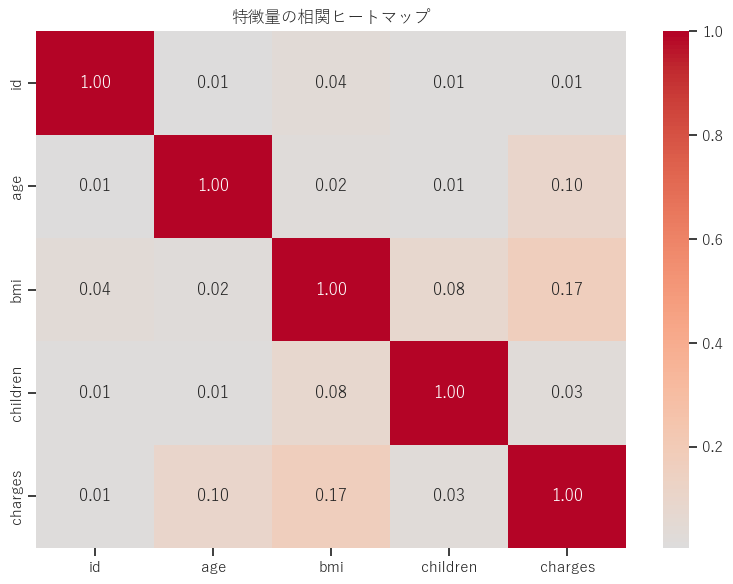

In [8]:
try:
    from pathlib import Path

    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

    num_df = df.select_dtypes(include=[np.number]).copy()
    if target_col in df.columns and target_col not in num_df.columns:
        try:
            num_df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
        except Exception:
            pass

    corr = num_df.corr(numeric_only=True)
    print('【相関行列】')
    print(corr)

    if corr.shape[0] > 0:
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=False)
        plt.title('特徴量の相関ヒートマップ')
        plt.tight_layout()
        plt.savefig(Path(FIG_DIR) / 'feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: corr_code: {_eda_exc}")
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    fig, ax = plt.subplots(figsize=(10, 8))
    if len(numeric_cols) >= 2:
        corr = df[numeric_cols[:20]].corr(numeric_only=True)
        sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
        ax.set_title("数値特徴量の相関ヒートマップ（先頭20列）")
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "相関分析に十分な数値列がありません", ha="center", va="center", fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "feature_correlation_heatmap.png", dpi=160, bbox_inches="tight")
    plt.show()


## 7. 日付分析


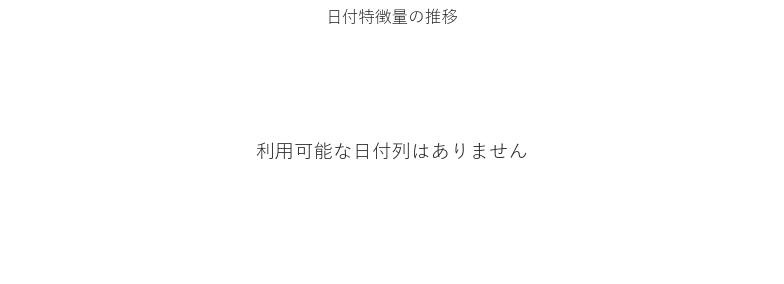

【日付列】
該当なし


In [9]:
try:
    from pathlib import Path

    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

    def is_pure_day_number_column(series):
        s = pd.to_numeric(series, errors='coerce')
        valid = s.dropna()
        if len(valid) == 0:
            return False
        return valid.between(1, 31).all()

    selected_date_col = None
    if date_col_hint is not None and str(date_col_hint).lower() != 'none' and date_col_hint in df.columns:
        if not is_pure_day_number_column(df[date_col_hint]):
            converted = pd.to_datetime(df[date_col_hint], errors='coerce')
            if converted.notna().sum() > 0:
                selected_date_col = date_col_hint
    else:
        for col in df.columns:
            if is_pure_day_number_column(df[col]):
                continue
            if df[col].dtype == 'object' or str(df[col].dtype).startswith('datetime'):
                converted = pd.to_datetime(df[col], errors='coerce')
                if converted.notna().sum() > 0:
                    selected_date_col = col
                    break

    if selected_date_col is not None:
        temp = df[[selected_date_col] + ([target_col] if target_col in df.columns else [])].copy()
        temp[selected_date_col] = pd.to_datetime(temp[selected_date_col], errors='coerce')
        temp = temp.dropna(subset=[selected_date_col])
        temp = temp.sort_values(selected_date_col)
        if target_col in temp.columns and pd.api.types.is_numeric_dtype(temp[target_col]):
            trend = temp.set_index(selected_date_col)[target_col].resample('M').mean()
        else:
            trend = temp.set_index(selected_date_col).resample('M').size()
        plt.figure(figsize=(10, 4.5))
        plt.plot(trend.index, trend.values, marker='o', color='darkorange')
        plt.xlabel('日付')
        plt.ylabel('平均値' if target_col in temp.columns and pd.api.types.is_numeric_dtype(temp[target_col]) else '件数')
        plt.title('日付特徴量の推移')
        plt.tight_layout()
        plt.savefig(Path(FIG_DIR) / 'date_feature_trend.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
        print('【日付列】')
        print(selected_date_col)
    else:
        plt.figure(figsize=(8, 3))
        plt.text(0.5, 0.5, '利用可能な日付列はありません', ha='center', va='center', fontsize=14)
        plt.axis('off')
        plt.title('日付特徴量の推移')
        plt.tight_layout()
        plt.savefig(Path(FIG_DIR) / 'date_feature_trend.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
        print('【日付列】')
        print('該当なし')
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: date_code: {_eda_exc}")
    date_col = "None".strip() or date_col_hint
    fig, ax = plt.subplots(figsize=(12, 4))
    if date_col and date_col in df.columns and date_col != target_col:
        pure_day = is_pure_day_number_column(df[date_col])
        if pure_day:
            ax.axis("off")
            ax.text(0.5, 0.5, f"{date_col} は純粋な日番号列のため日付展開を行いません", ha="center", va="center", fontsize=12)
        else:
            parsed = pd.to_datetime(df[date_col], errors="coerce")
            valid = parsed.notna()
            if valid.sum() > 0:
                tmp = df.loc[valid, [target_col]].copy()
                tmp["_date"] = parsed.loc[valid]
                if pd.api.types.is_numeric_dtype(tmp[target_col]):
                    monthly = tmp.set_index("_date")[target_col].resample("M").mean()
                    monthly.plot(ax=ax, color="#4e79a7", marker="o")
                    ax.set_title("月次の目的変数平均")
                    ax.set_ylabel("平均値")
                else:
                    monthly = tmp.assign(_value=1).set_index("_date")["_value"].resample("M").sum()
                    monthly.plot(ax=ax, color="#4e79a7", marker="o")
                    ax.set_title("月次レコード件数")
                    ax.set_ylabel("件数")
                ax.set_xlabel("日付")
            else:
                ax.axis("off")
                ax.text(0.5, 0.5, f"{date_col} を日付として解釈できませんでした", ha="center", va="center", fontsize=12)
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "日付分析対象列はありません", ha="center", va="center", fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "date_feature_trend.png", dpi=160, bbox_inches="tight")
    plt.show()


## 8. 観察結果サマリ


In [10]:
try:
    print('【EDAサマリー】')
    rows, cols = df.shape
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in df.columns if df[c].dtype == 'object' or str(df[c].dtype) == 'category']
    missing_total = int(df.isna().sum().sum())
    print(f'行数: {rows}')
    print(f'列数: {cols}')
    print(f'数値列数: {len(num_cols)}')
    print(f'カテゴリ列数: {len(cat_cols)}')
    print(f'総欠損数: {missing_total}')

    if target_col in df.columns:
        print('\n【目的変数の要約】')
        print(df[target_col].value_counts(dropna=False).sort_index())

    print('\n【列ごとのユニーク数】')
    print(df.nunique(dropna=True).sort_values(ascending=False))
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: summary_code: {_eda_exc}")
    summary_rows = []
    summary_rows.append(f"レコード数: {len(df):,}")
    summary_rows.append(f"列数: {df.shape[1]:,}")
    summary_rows.append(f"欠損率上位列: {', '.join((df.isna().mean()*100).sort_values(ascending=False).head(3).index.tolist())}")
    summary_rows.append(f"数値列数: {len(df.select_dtypes(include=['number']).columns)}")
    summary_rows.append(f"カテゴリ列数: {len([c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])])}")
    summary_rows.append(f"目的変数候補: {target_col}")
    print("主要サマリ")
    for row in summary_rows:
        print(f"- {row}")


【EDAサマリー】
行数: 1600
列数: 8
数値列数: 5
カテゴリ列数: 0
総欠損数: 0

【目的変数の要約】
charges
0    1256
1     198
2     146
Name: count, dtype: int64

【列ごとのユニーク数】
id          1600
bmi         1600
age           47
children       6
region         4
charges        3
sex            2
smoker         2
dtype: int64
